<h1 style="
    text-align:center;
    background-color:#004F98;
    color:white;
    padding:20px;
    border-radius:10px;">
    🏘️📉 Boston Housing Price Prediction — Support Vector Regressor (SVR)
</h1>
<p style="text-align:center;color:#1F4E79;font-size:1rem;margin-top:10px;">
<b>Records:</b> 506 &nbsp;|&nbsp; <b>Features:</b> 13 &nbsp;|&nbsp; <b>Target:</b> Median House Value (MEDV) &nbsp;|&nbsp; <b>Avg Price:</b> $22.5K
</p>

<h2 style="color:#2E86C1;">
 1️⃣ 📚 Import Libraries
</h2>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.svm              import SVR
from sklearn.metrics          import (mean_squared_error, mean_absolute_error,
                                       r2_score, mean_absolute_percentage_error)
import pickle


<h2 style="color:#2E86C1;">
2️⃣ 🎯📖 Reading Dataset
</h2>

In [61]:
data = pd.read_csv('BostonHousing.csv')
df   = data.copy()
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<h2 style="color:#2E86C1;">
3️⃣ 𝄜 Data Shape
</h2>

In [62]:
print(f"  𝄜 Data Shape :{df.shape}")

  𝄜 Data Shape :(506, 14)


In [63]:
print(f'(☰)  Number of rows: {df.shape[0]}')
print(f'(|||) Number of columns: {df.shape[1]}')

(☰)  Number of rows: 506
(|||) Number of columns: 14


<h2 style="color:#2E86C1;">
4️⃣ 🔍 Initial Data Exploration
</h2>

In [64]:
print('📌 First 10 rows of the dataset:')
df.head(10)

📌 First 10 rows of the dataset:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [65]:
# Display last 5 rows
print('📌 Last 5 rows of the dataset:')
df.tail()

📌 Last 5 rows of the dataset:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [66]:
# General information about the dataset
print("\n" + "="*50 + "\n")
print('📋 Dataset Information:')
print(df.info())
print("\n" + "="*50 + "\n")



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None




In [67]:
# Column names
print("\n" + "="*100 + "\n")
print('📝 Column Names:')
print(df.columns.tolist())
print("\n" + "="*100 + "\n")



📝 Column Names:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']




In [68]:
# Descriptive statistics for numerical columns
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,501.0,6.284341,0.705587,3.56100,5.884000,6.20800,6.625000,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


<h2 style="color:#2E86C1;">
5️⃣ 🧹 Data Cleaning & Preprocessing
</h2>

In [69]:
# ── Feature engineering ──────────────────────────────────────
df['PriceCategory'] = pd.cut(
    df['medv'],
    bins=[0, 15, 25, 35, 60],
    labels=['Low (<$15K)', 'Medium ($15–25K)', 'High ($25–35K)', 'Very High (>$35K)']
)
df['NearRiver']    = df['chas'].map({1: 'Near River', 0: 'Not Near River'})
df['HighCrime']    = (df['crim'] > df['crim'].median()).map({True: 'High Crime', False: 'Low Crime'})
df['OldNeighborhood'] = (df['age'] > 75).map({True: 'Old (>75%)', False: 'Newer (≤75%)'})

df.head(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,PriceCategory,NearRiver,HighCrime,OldNeighborhood
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,Medium ($15–25K),Not Near River,Low Crime,Newer (≤75%)
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,Medium ($15–25K),Not Near River,Low Crime,Old (>75%)
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,High ($25–35K),Not Near River,Low Crime,Newer (≤75%)


In [70]:
# Check for missing values
print('❌ Missing Values in Each Column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No missing values found.")

❌ Missing Values in Each Column:
rm    5
dtype: int64


In [71]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f'🔍 Number of Duplicate Rows: {duplicates_count}')

🔍 Number of Duplicate Rows: 0


In [72]:
# Check for duplicate Columns
duplicates_count = df.T.duplicated().sum()
print(f'🔍 Number of Duplicate Columns: {duplicates_count}')

🔍 Number of Duplicate Columns: 0


In [73]:
print('='*60)
print('  DATASET OVERVIEW')
print('='*60)
print(f'  Total Records      : {df.shape[0]:,}')
print(f'  Total Features     : {df.shape[1]}')
print(f'  Price Range        : ${df["medv"].min():.1f}K  →  ${df["medv"].max():.1f}K')
print(f'  Avg House Price    : ${df["medv"].mean():.2f}K')
print(f'  Median House Price : ${df["medv"].median():.2f}K')
print(f'  Near River         : {df["chas"].sum()} properties  ({df["chas"].mean()*100:.1f}%)')
print(f'  Avg Rooms (rm)     : {df["rm"].mean():.2f}')
print(f'  Avg Crime Rate     : {df["crim"].mean():.4f}')
print(f'  Avg Pupil-Teacher  : {df["ptratio"].mean():.2f}')
print('='*60)

  DATASET OVERVIEW
  Total Records      : 506
  Total Features     : 18
  Price Range        : $5.0K  →  $50.0K
  Avg House Price    : $22.53K
  Median House Price : $21.20K
  Near River         : 35 properties  (6.9%)
  Avg Rooms (rm)     : 6.28
  Avg Crime Rate     : 3.6135
  Avg Pupil-Teacher  : 18.46


In [74]:
# Descriptive statistics for numerical columns
print('📊 Descriptive Statistics (Numerical):')
df.describe().T

📊 Descriptive Statistics (Numerical):


,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,501.0,6.284341,0.705587,3.56100,5.884000,6.20800,6.625000,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


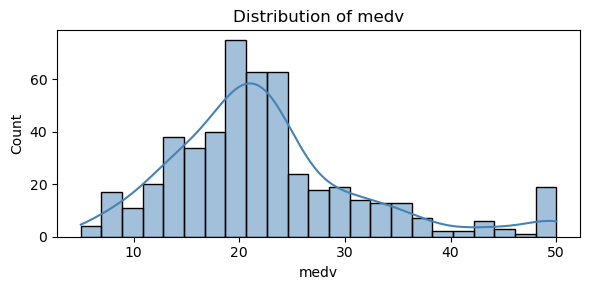

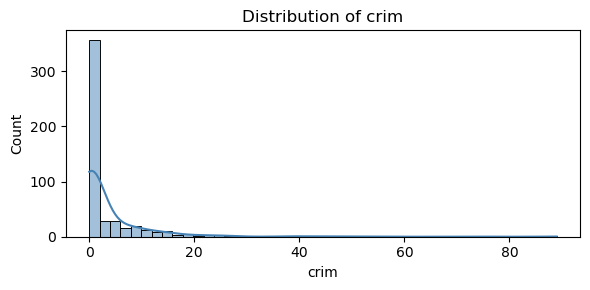

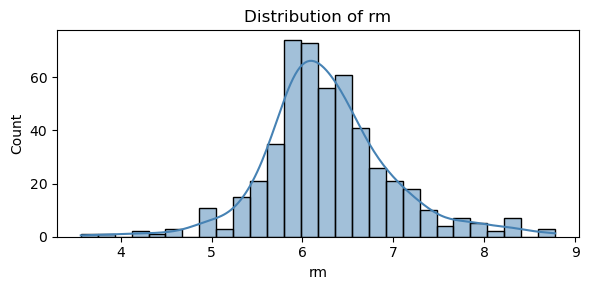

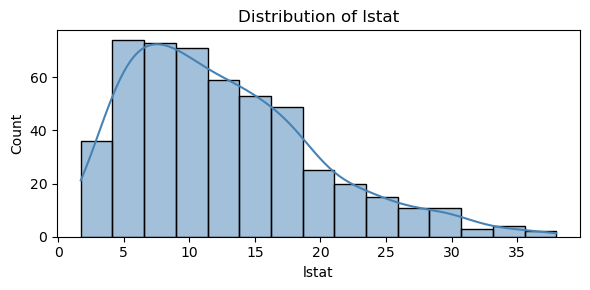

In [75]:
# Distribution of key features
key_cols = ['medv', 'crim', 'rm', 'lstat']
for col in key_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

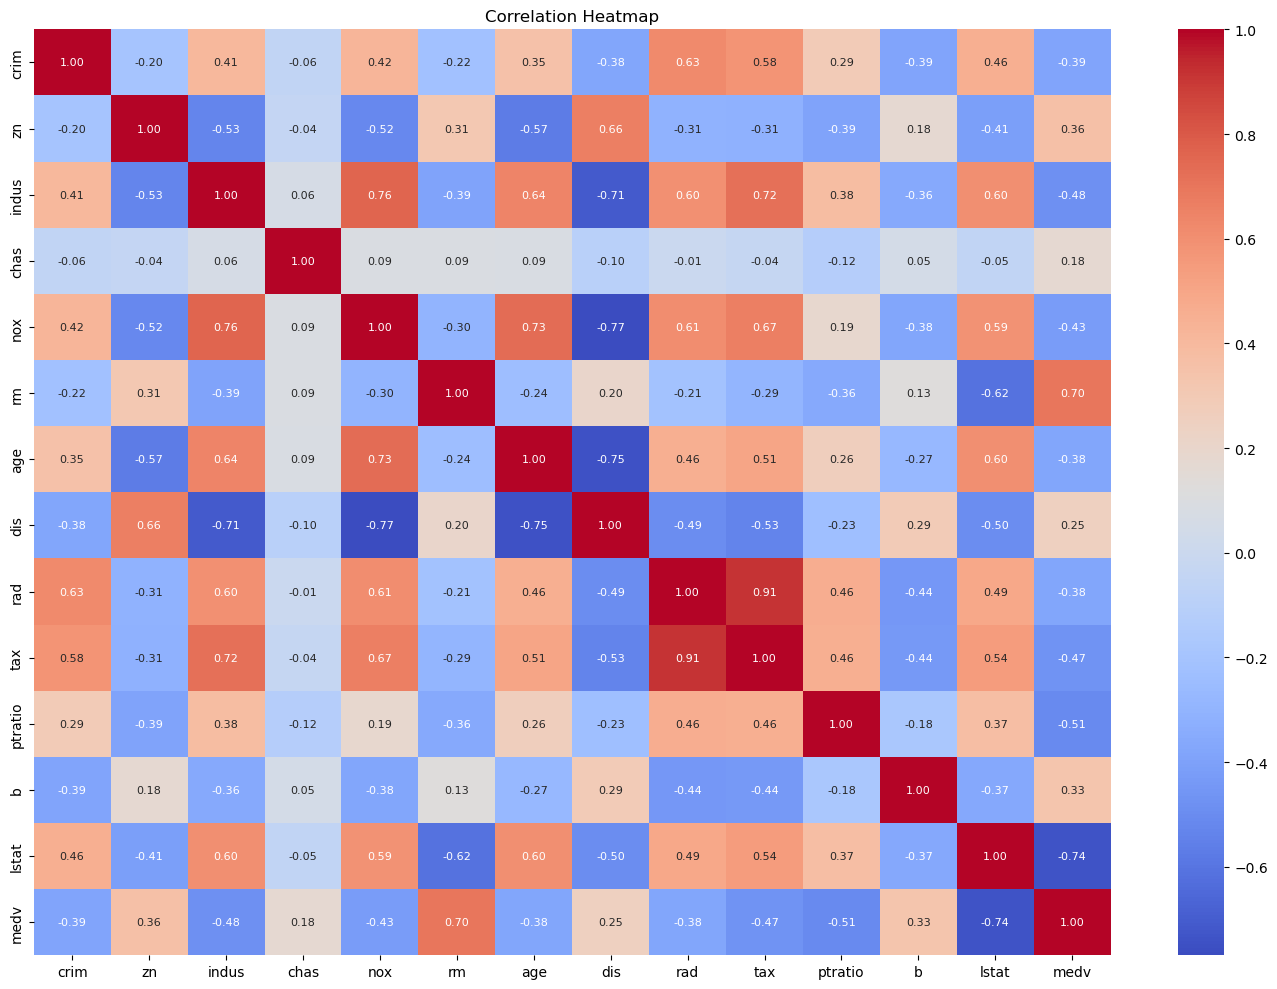

In [76]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<h2 style="color:#2E86C1;">
6️⃣ 📈 Analysis Data
</h2>

📊  Housing Price KPI :

In [77]:
Total_Properties   = df.shape[0]
Avg_Price          = df['medv'].mean()
Median_Price       = df['medv'].median()
Max_Price          = df['medv'].max()
Min_Price          = df['medv'].min()
Std_Price          = df['medv'].std()
Avg_Rooms          = df['rm'].mean()
Near_River_Count   = df['chas'].sum()

print('='*60)
print('  HOUSING PRICE KPIs')
print('='*60)
print(f'  Total Properties    : {Total_Properties:,}')
print(f'  Avg House Price     : ${Avg_Price:.2f}K')
print(f'  Median House Price  : ${Median_Price:.2f}K')
print(f'  Max House Price     : ${Max_Price:.1f}K')
print(f'  Min House Price     : ${Min_Price:.1f}K')
print(f'  Std Dev             : ${Std_Price:.2f}K')
print(f'  Avg Rooms           : {Avg_Rooms:.2f}')
print(f'  Near River          : {Near_River_Count} properties')
print('='*60)

  HOUSING PRICE KPIs
  Total Properties    : 506
  Avg House Price     : $22.53K
  Median House Price  : $21.20K
  Max House Price     : $50.0K
  Min House Price     : $5.0K
  Std Dev             : $9.20K
  Avg Rooms           : 6.28
  Near River          : 35 properties


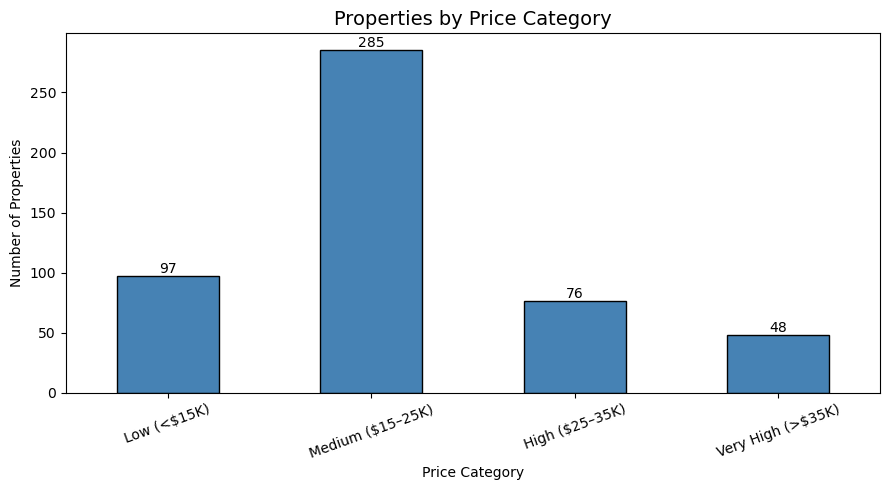

In [78]:
# Price category distribution — bar chart
price_counts = df['PriceCategory'].value_counts().sort_index()
ax = price_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black',
    figsize=(9, 5)
)
plt.title('Properties by Price Category', fontsize=14)
plt.xlabel('Price Category')
plt.ylabel('Number of Properties')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

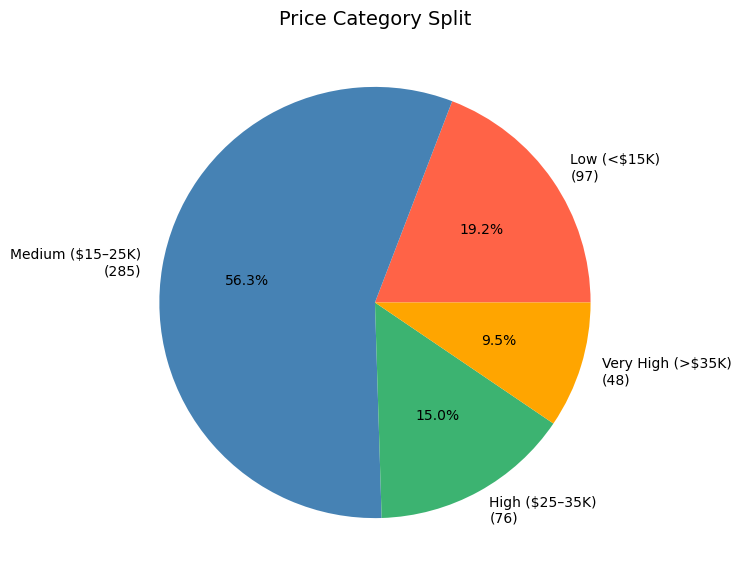

In [79]:
# Price category pie chart
price_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7),
    colors=['tomato', 'steelblue', 'mediumseagreen', 'orange'],
    labels=[f'{c}\n({v})' for c, v in zip(price_counts.index, price_counts.values)]
)
plt.title('Price Category Split', fontsize=14)
plt.ylabel('')
plt.show()

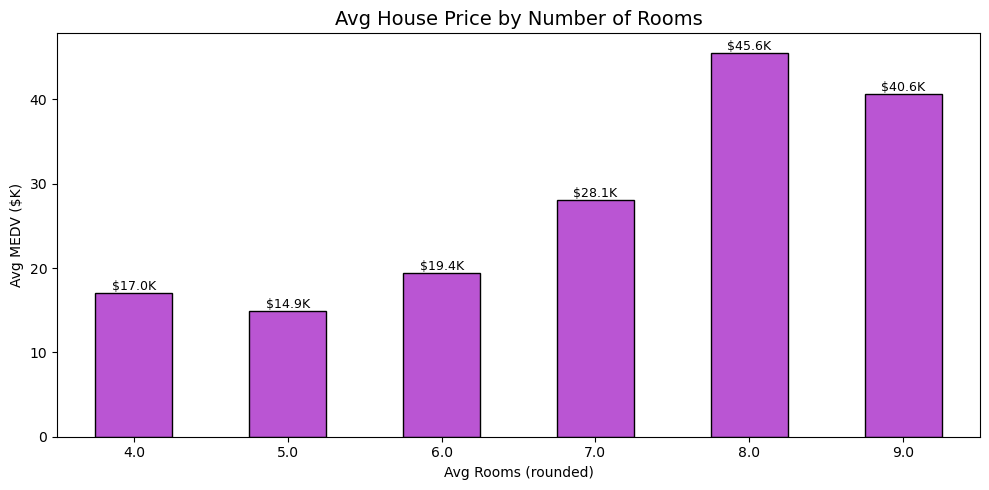

In [80]:
# Average price by number of rooms (rounded)
df['rm_rounded'] = df['rm'].round()
price_by_rooms = df.groupby('rm_rounded')['medv'].mean().sort_index()

ax = price_by_rooms.plot(
    kind='bar',
    color='mediumorchid',
    edgecolor='black',
    figsize=(10, 5)
)
plt.title('Avg House Price by Number of Rooms', fontsize=14)
plt.xlabel('Avg Rooms (rounded)')
plt.ylabel('Avg MEDV ($K)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

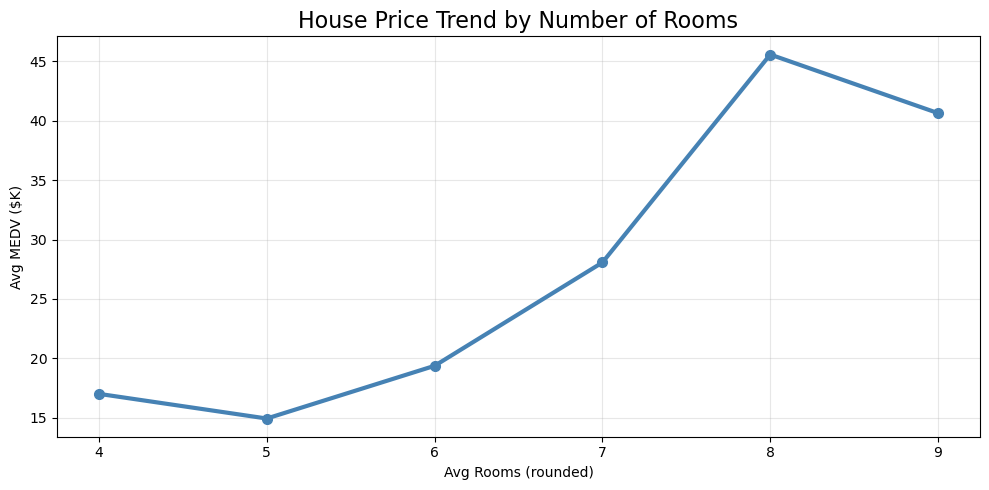

In [81]:



# Price trend by rooms — line chart
price_by_rooms.plot(
    kind='line',
    marker='o',
    ms=7,
    linewidth=3,
    figsize=(10, 5),
    color='steelblue'
)
plt.title('House Price Trend by Number of Rooms', fontsize=16)
plt.xlabel('Avg Rooms (rounded)')
plt.ylabel('Avg MEDV ($K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

📊  Area / Zone KPI :

In [82]:
zone_kpi = df.groupby('HighCrime').agg(
    Properties  = ('medv',    'count'),
    Avg_Price   = ('medv',    'mean'),
    Avg_Rooms   = ('rm',      'mean'),
    Avg_lstat   = ('lstat',   'mean'),
    Avg_ptratio = ('ptratio', 'mean')
).round(2)
zone_kpi

,Properties,Avg_Price,Avg_Rooms,Avg_lstat,Avg_ptratio
HighCrime,,,,,
High Crime,253,20.12,6.17,15.89,19.00
Low Crime,253,24.95,6.40,9.42,17.91


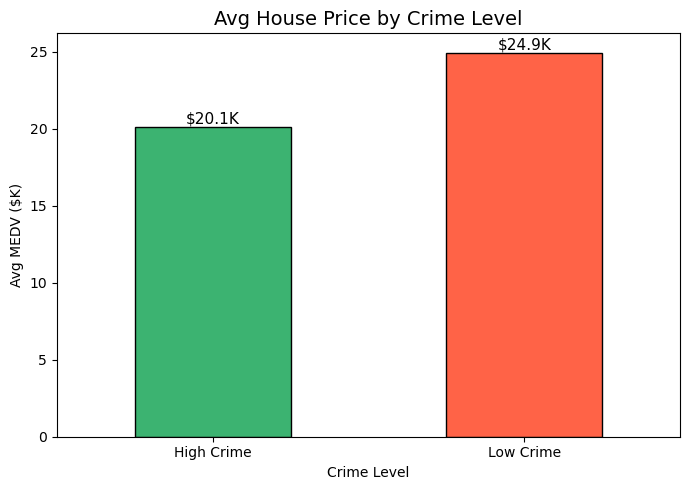

In [83]:
# Avg price by crime level
crime_price = df.groupby('HighCrime')['medv'].mean()
ax = crime_price.plot(
    kind='bar',
    color=['mediumseagreen', 'tomato'],
    edgecolor='black',
    figsize=(7, 5)
)
plt.title('Avg House Price by Crime Level', fontsize=14)
plt.xlabel('Crime Level')
plt.ylabel('Avg MEDV ($K)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

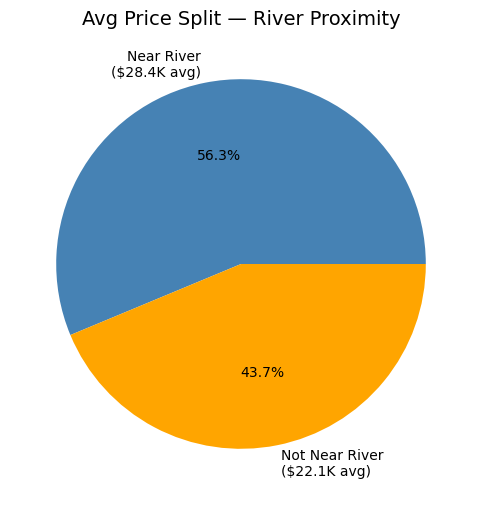

In [84]:
# Near River vs Not Near River — avg price
river_price = df.groupby('NearRiver')['medv'].mean()
river_price.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    colors=['steelblue', 'orange'],
    labels=[f'{c}\n(${v:.1f}K avg)' for c, v in zip(river_price.index, river_price.values)]
)
plt.title('Avg Price Split — River Proximity', fontsize=14)
plt.ylabel('')
plt.show()

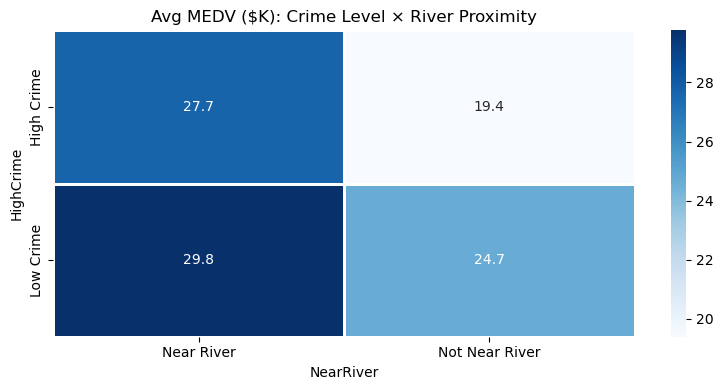

In [85]:
# Price by crime level × river proximity
cross_tab = df.groupby(['HighCrime', 'NearRiver'])['medv'].mean().reset_index()
pivot_cross = cross_tab.pivot(index='HighCrime', columns='NearRiver', values='medv').fillna(0)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_cross, annot=True, fmt='.1f', cmap='Blues', linewidths=2)
plt.title('Avg MEDV ($K): Crime Level × River Proximity')
plt.tight_layout()
plt.show()

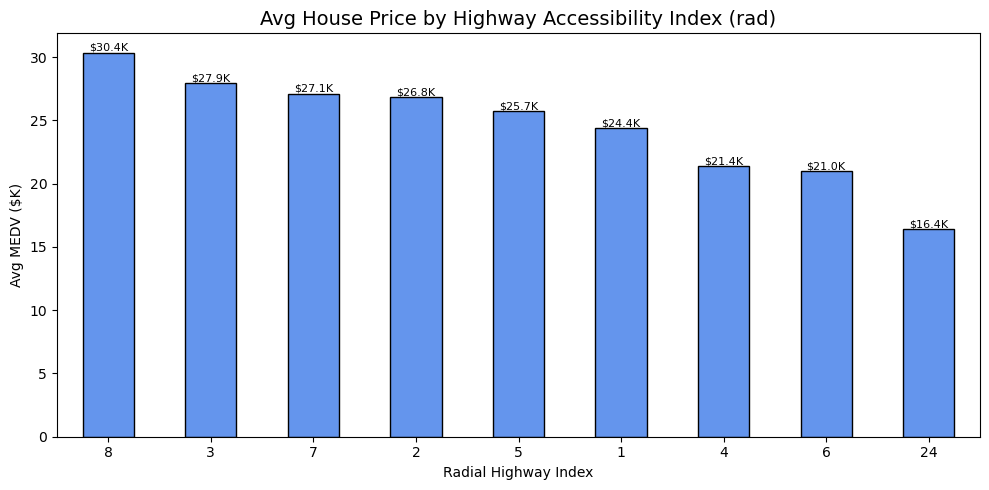

In [86]:
# Top 10 areas by avg price (by rad index as zone proxy)
price_by_rad = df.groupby('rad')['medv'].mean().sort_values(ascending=False)
ax = price_by_rad.plot(
    kind='bar',
    color='cornflowerblue',
    edgecolor='black',
    figsize=(10, 5)
)
plt.title('Avg House Price by Highway Accessibility Index (rad)', fontsize=14)
plt.xlabel('Radial Highway Index')
plt.ylabel('Avg MEDV ($K)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

📊  Neighborhood Demographics KPI :

In [87]:
neighborhood_kpi = df.groupby('OldNeighborhood').agg(
    Avg_Price   = ('medv',   'mean'),
    Avg_Crime   = ('crim',   'mean'),
    Avg_Rooms   = ('rm',     'mean'),
    Avg_lstat   = ('lstat',  'mean'),
    Properties  = ('medv',   'count')
).round(3)
neighborhood_kpi

,Avg_Price,Avg_Crime,Avg_Rooms,Avg_lstat,Properties
OldNeighborhood,,,,,
Newer (≤75%),25.906,0.549,6.430,8.561,244
Old (>75%),19.391,6.468,6.149,16.464,262


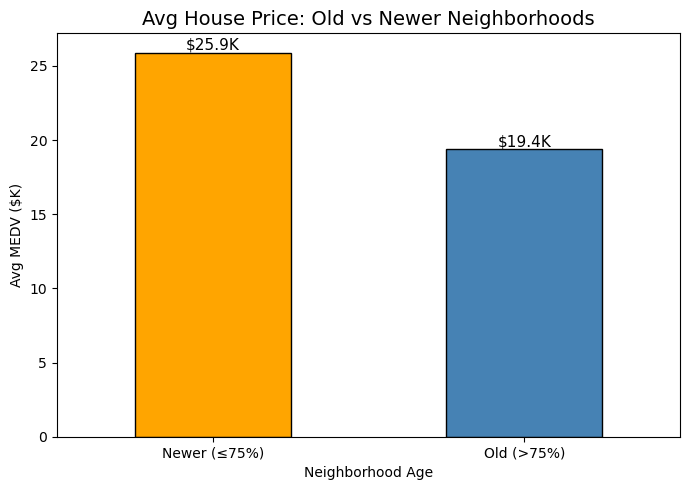

In [88]:
# Old vs newer neighbourhood bar chart
old_new = df.groupby('OldNeighborhood')['medv'].mean()
ax = old_new.plot(
    kind='bar',
    color=['orange', 'steelblue'],
    edgecolor='black',
    figsize=(7, 5)
)
plt.title('Avg House Price: Old vs Newer Neighborhoods', fontsize=14)
plt.xlabel('Neighborhood Age')
plt.ylabel('Avg MEDV ($K)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\1305791325.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lstat_price = df.groupby(lstat_bins)['medv'].mean()


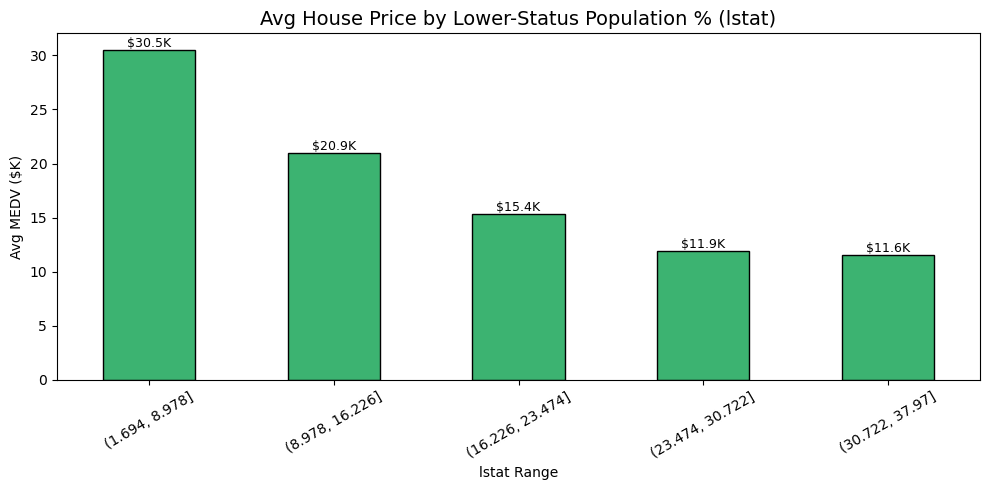

In [89]:
# lstat (lower status %) vs price — grouped bar
lstat_bins = pd.cut(df['lstat'], bins=5)
lstat_price = df.groupby(lstat_bins)['medv'].mean()

ax = lstat_price.plot(
    kind='bar',
    color='mediumseagreen',
    edgecolor='black',
    figsize=(10, 5)
)
plt.title('Avg House Price by Lower-Status Population % (lstat)', fontsize=14)
plt.xlabel('lstat Range')
plt.ylabel('Avg MEDV ($K)')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

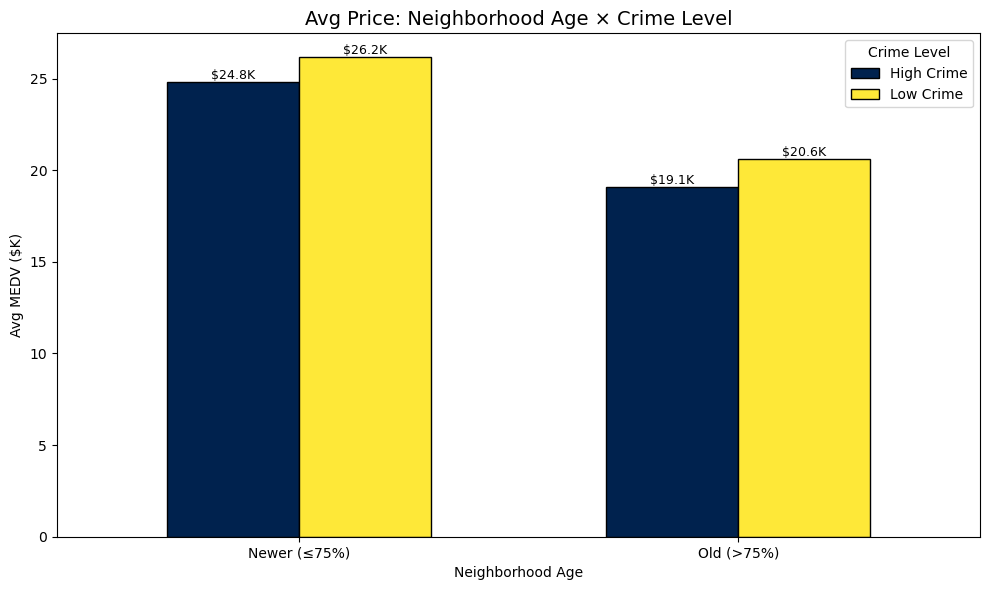

In [90]:
# Crime × Neighborhood age
crime_old = df.groupby(['OldNeighborhood', 'HighCrime'])['medv'].mean().reset_index()
pivot_c_o = crime_old.pivot(index='OldNeighborhood', columns='HighCrime', values='medv').fillna(0)

ax = pivot_c_o.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    width=0.6,
    colormap='cividis'
)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.1fK', fontsize=9)
plt.title('Avg Price: Neighborhood Age × Crime Level', fontsize=14)
plt.xlabel('Neighborhood Age')
plt.ylabel('Avg MEDV ($K)')
plt.xticks(rotation=0)
plt.legend(title='Crime Level')
plt.tight_layout()
plt.show()

📊  Feature Behavior KPI :

In [91]:
feature_kpi = df.groupby('PriceCategory').agg(
    Avg_rm      = ('rm',      'mean'),
    Avg_lstat   = ('lstat',   'mean'),
    Avg_ptratio = ('ptratio', 'mean'),
    Avg_crim    = ('crim',    'mean'),
    Avg_nox     = ('nox',     'mean'),
    Avg_dis     = ('dis',     'mean')
).round(3)
feature_kpi

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\2596039593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_kpi = df.groupby('PriceCategory').agg(


,Avg_rm,Avg_lstat,Avg_ptratio,Avg_crim,Avg_nox,Avg_dis
PriceCategory,,,,,,
Low (<$15K),5.873,22.279,19.962,13.242,0.671,2.103
Medium ($15–25K),6.089,12.250,18.652,1.561,0.542,4.124
High ($25–35K),6.756,6.926,17.126,0.632,0.478,4.797
Very High (>$35K),7.503,4.661,16.350,1.064,0.515,3.673


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\2142622115.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lstat_medv = df.groupby(lstat_bins_line)['medv'].mean()


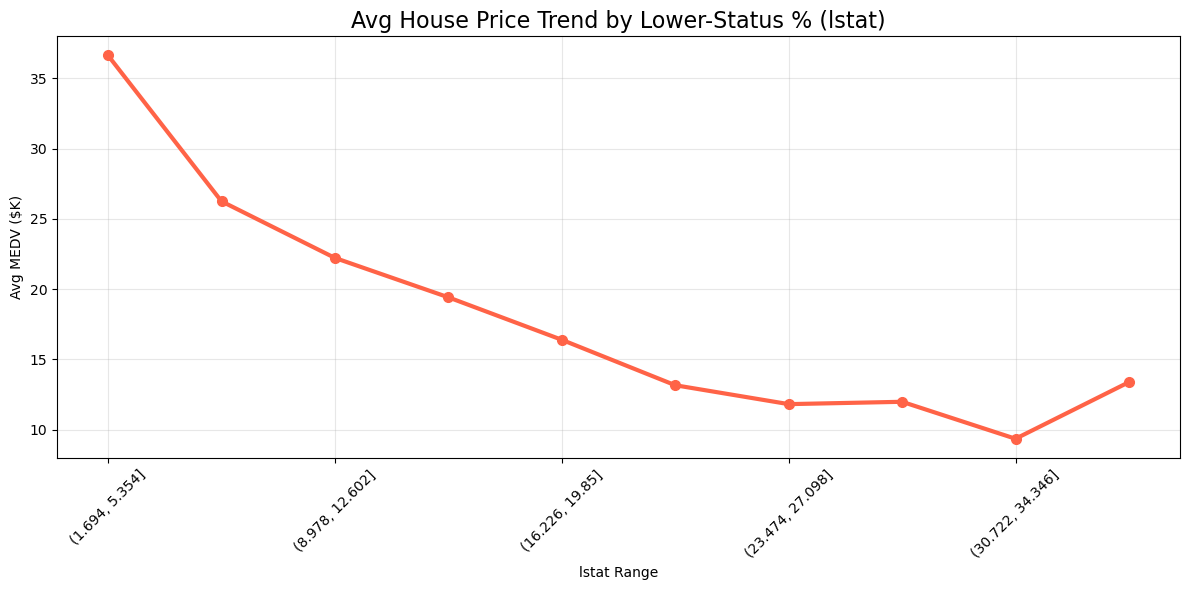

In [92]:
# lstat vs MEDV line trend
lstat_bins_line = pd.cut(df['lstat'], bins=10)
lstat_medv = df.groupby(lstat_bins_line)['medv'].mean()

lstat_medv.plot(
    kind='line',
    marker='o',
    ms=7,
    linewidth=3,
    figsize=(12, 6),
    color='tomato'
)
plt.title('Avg House Price Trend by Lower-Status % (lstat)', fontsize=16)
plt.xlabel('lstat Range')
plt.ylabel('Avg MEDV ($K)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

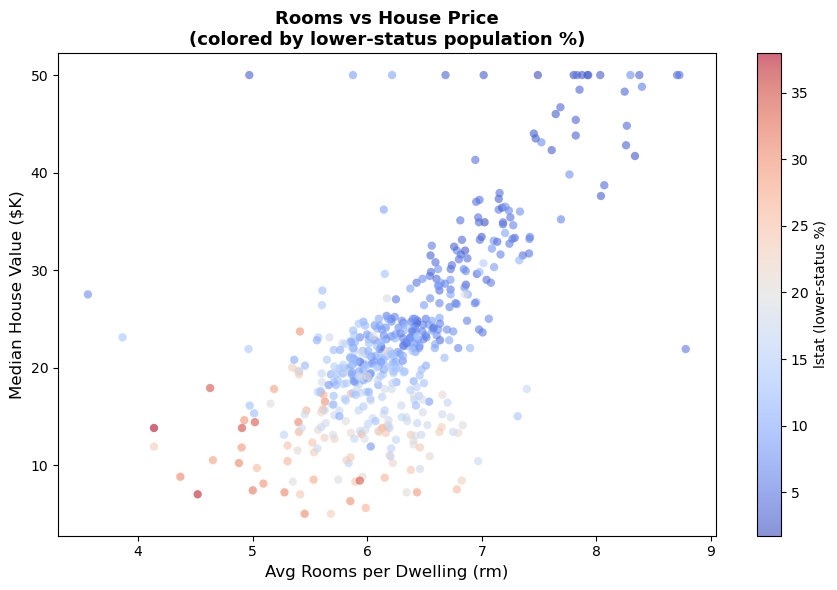

In [93]:
# rm vs MEDV scatter (coloured by price category)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['rm'],
    df['medv'],
    c=df['lstat'],
    cmap='coolwarm', alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, label='lstat (lower-status %)')
plt.xlabel('Avg Rooms per Dwelling (rm)', fontsize=12)
plt.ylabel('Median House Value ($K)', fontsize=12)
plt.title('Rooms vs House Price\n(colored by lower-status population %)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\4146859674.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_feat_price = df.groupby('PriceCategory')[feat_heat_cols].mean()


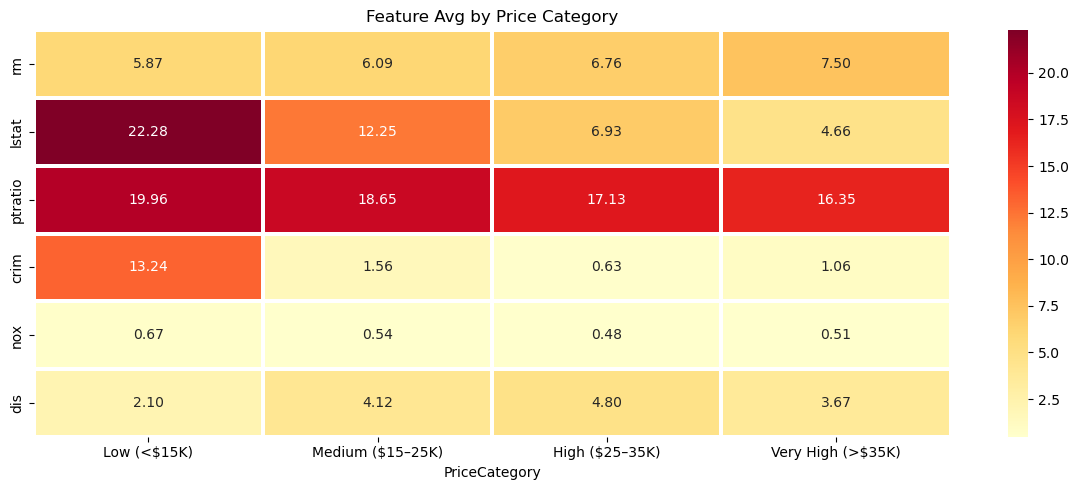

In [94]:
# Feature avg by price category heatmap
feat_heat_cols = ['rm', 'lstat', 'ptratio', 'crim', 'nox', 'dis']
pivot_feat_price = df.groupby('PriceCategory')[feat_heat_cols].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_feat_price.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=1.5)
plt.title('Feature Avg by Price Category')
plt.tight_layout()
plt.show()

In [95]:
# ── KEY INSIGHTS & RECOMMENDATIONS ──────────────────────────
top_price_cat   = df.groupby('PriceCategory')['medv'].count().idxmax()
best_rm         = df.groupby('rm_rounded')['medv'].mean().idxmax()
river_premium   = df[df['chas']==1]['medv'].mean() - df[df['chas']==0]['medv'].mean()
crime_penalty   = df[df['HighCrime']=='Low Crime']['medv'].mean() - df[df['HighCrime']=='High Crime']['medv'].mean()
top_lstat_cut   = float(str(df.groupby(pd.cut(df['lstat'],bins=5))['medv'].mean().idxmin()).split(',')[0].strip('('))

insights = [
    ('🏠 Most Common Price Band',  f'Most properties fall in the "{top_price_cat}" bracket.'),
    ('🛏️  Rooms Sweet Spot',       f'{int(best_rm)}-room properties achieve the highest avg price.'),
    ('🌊 River Premium',           f'River-adjacent homes command ~${river_premium:.1f}K premium.'),
    ('🚨 Crime Penalty',           f'Low-crime areas avg ${crime_penalty:.1f}K more than high-crime areas.'),
    ('📉 lstat Effect',            'Higher lower-status population % strongly depresses house value.'),
    ('🎓 School Quality',          'ptratio (pupil-teacher ratio) inversely correlates with price.'),
    ('💨 Air Quality',             'nox (nitrogen oxides) negatively impacts house value.'),
]

print('='*65)
print('  KEY INSIGHTS & STRATEGIC TAKEAWAYS')
print('='*65)
for title, detail in insights:
    print(f'  {title}')
    print(f'     → {detail}')
    print()

print('INVESTMENT RECOMMENDATIONS')
print('-'*65)
recs = [
    f'1. Target {int(best_rm)}-room properties — highest avg price per property.',
    '2. River-adjacent (chas=1) properties command a significant premium.',
    '3. Prioritise low-crime zones — strong positive effect on MEDV.',
    '4. lstat < 10 neighbourhoods consistently deliver the highest prices.',
    '5. Low ptratio (better schools) areas correlate with premium pricing.',
    '6. SVR with RBF kernel best captures the non-linear lstat–MEDV relationship.',
]
for r in recs:
    print(f'  {r}')
print('='*65)

  KEY INSIGHTS & STRATEGIC TAKEAWAYS
  🏠 Most Common Price Band
     → Most properties fall in the "Medium ($15–25K)" bracket.

  🛏️  Rooms Sweet Spot
     → 8-room properties achieve the highest avg price.

  🌊 River Premium
     → River-adjacent homes command ~$6.3K premium.

  🚨 Crime Penalty
     → Low-crime areas avg $4.8K more than high-crime areas.

  📉 lstat Effect
     → Higher lower-status population % strongly depresses house value.

  🎓 School Quality
     → ptratio (pupil-teacher ratio) inversely correlates with price.

  💨 Air Quality
     → nox (nitrogen oxides) negatively impacts house value.

INVESTMENT RECOMMENDATIONS
-----------------------------------------------------------------
  1. Target 8-room properties — highest avg price per property.
  2. River-adjacent (chas=1) properties command a significant premium.
  3. Prioritise low-crime zones — strong positive effect on MEDV.
  4. lstat < 10 neighbourhoods consistently deliver the highest prices.
  5. Low ptratio 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\1823640357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_price_cat   = df.groupby('PriceCategory')['medv'].count().idxmax()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9352\1823640357.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_lstat_cut   = float(str(df.groupby(pd.cut(df['lstat'],bins=5))['medv'].mean().idxmin()).split(',')[0].strip('('))


<h2 style="color:#2E86C1;">
6️⃣ 🔧 Define Features & Target
</h2>

In [96]:
# ── All 13 original numerical features ───────────────────────
num_features = [
    'crim', 'zn', 'indus', 'chas', 'nox',
    'rm', 'age', 'dis', 'rad', 'tax',
    'ptratio', 'b', 'lstat'
]

# ── Categorical features ──────────────────────────────────────
cat_features = []   # all features are numerical in Boston Housing

# ── Target ───────────────────────────────────────────────────
TARGET = 'medv'

print('='*55)
print('  FEATURE SETUP')
print('='*55)
print(f'  Numerical   ({len(num_features)}) : {num_features}')
print(f'  Categorical ({len(cat_features)}) : {cat_features}')
print(f'  Target               : {TARGET}  (Median House Value in $1000s)')
print('='*55)

  FEATURE SETUP
  Numerical   (13) : ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
  Categorical (0) : []
  Target               : medv  (Median House Value in $1000s)


In [97]:
X = df[num_features]
y = df[TARGET]

print(f'📌 X shape : {X.shape}')
print(f'📌 y shape : {y.shape}')
print(f'📌 Target distribution :')
print(f'   Min    : ${y.min():.1f}K')
print(f'   Max    : ${y.max():.1f}K')
print(f'   Mean   : ${y.mean():.2f}K')
print(f'   Median : ${y.median():.2f}K')

📌 X shape : (506, 13)
📌 y shape : (506,)
📌 Target distribution :
   Min    : $5.0K
   Max    : $50.0K
   Mean   : $22.53K
   Median : $21.20K


# ✂️ Train-Test Split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('='*45)
print('  TRAIN / TEST SPLIT')
print('='*45)
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test     samples : {X_test.shape[0]}')
print(f'  Test size        : 20%')
print(f'  Stratified       : ❌ Not needed for regression')
print('='*45)

  TRAIN / TEST SPLIT
  Training samples : 404
  Test     samples : 102
  Test size        : 20%
  Stratified       : ❌ Not needed for regression


<h2 style="color:#2E86C1;">
7️⃣ ⚙️ Build the Pipeline
</h2>

In [135]:
# ── Step 1 : Preprocessor ─────────────────────────────────────
# SimpleImputer handles the 5 missing 'rm' values inside the pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_features)
])

model = SVR(
    kernel="rbf",
    C=100,
    epsilon=1,
    gamma="scale"
)

# ── Step 2 : Full Pipeline ────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',   model)
])

print('✅ Pipeline built successfully!')
print()
print(pipeline)

✅ Pipeline built successfully!

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['crim', 'zn', 'indus',
                                                   'chas', 'nox', 'rm', 'age',
                                                   'dis', 'rad', 'tax',
                                                   'ptratio', 'b',
                                                   'lstat'])])),
                ('regressor', SVR(C=100, epsilon=1))])


<h2 style="color:#2E86C1;">
8️⃣ 🚀 Train the Pipeline
</h2>

In [136]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [137]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [138]:
train_acc =r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9695052480094557
Test Accuracy: 0.8256592925362815


<h2 style="color:#2E86C1;">
9️⃣ 📊 Model Evaluation
</h2>

In [139]:
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print('='*50)
print('  MODEL PERFORMANCE')
print('='*50)
print(f'  📐 RMSE  : {rmse:.4f}  (avg ${rmse*1000:,.0f} error)')
print(f'  📉 MAE   : {mae:.4f}')
print(f'  📈 R²    : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  📊 MAPE  : {mape:.2f}%')
print('='*50)

  MODEL PERFORMANCE
  📐 RMSE  : 3.5756  (avg $3,576 error)
  📉 MAE   : 2.1544
  📈 R²    : 0.8257  (82.6% variance explained)
  📊 MAPE  : 11.83%


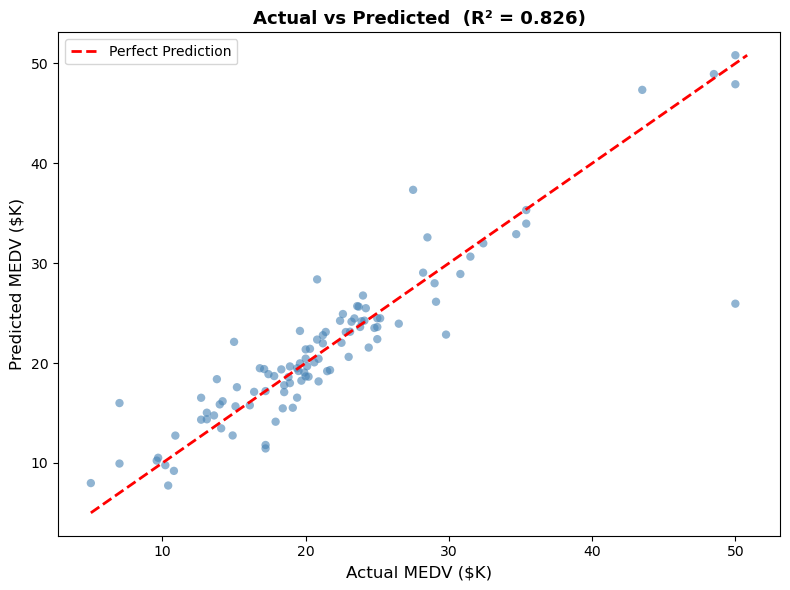

In [140]:
# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='none', color='steelblue')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual MEDV ($K)', fontsize=12)
plt.ylabel('Predicted MEDV ($K)', fontsize=12)
plt.title(f'Actual vs Predicted  (R² = {r2:.3f})', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

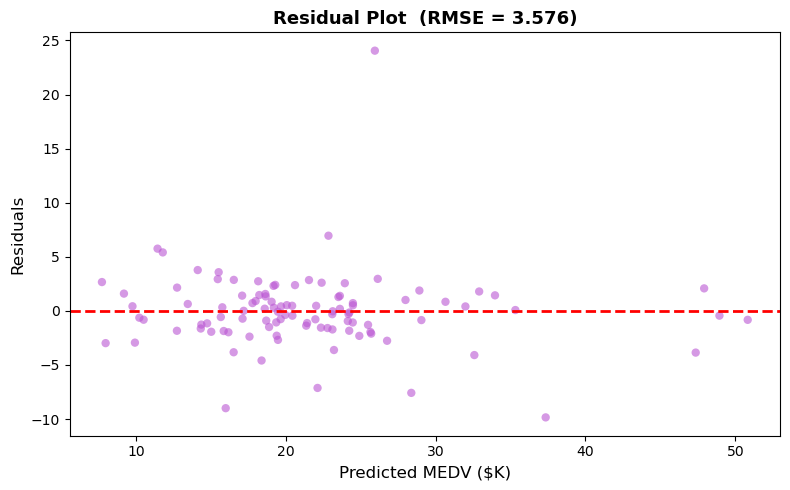

In [141]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='none', color='mediumorchid')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted MEDV ($K)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Residual Plot  (RMSE = {rmse:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📌 13) Overfitting Check

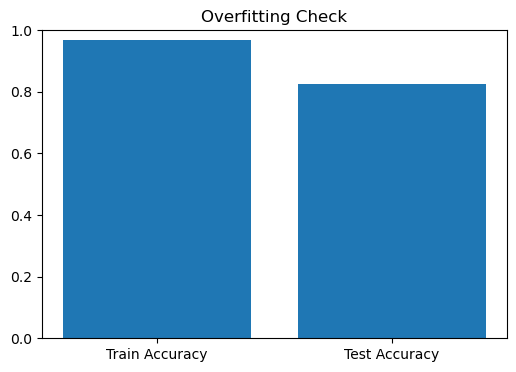

In [145]:
plt.figure(figsize=(6,4))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.title("Overfitting Check")
plt.ylim(0,1)
plt.show()

# 🧪 Test New Sample

In [142]:
def predict_sample(sample_dict):
    sample_df = pd.DataFrame([sample_dict])
    prediction = pipeline.predict(sample_df)[0]
    print(f'  Predicted House Price : ${prediction:.2f}K  (${prediction*1000:,.0f})')
    return prediction

In [143]:
new_property = {
    'crim':    0.05,     # low crime
    'zn':      25.0,     # residential zoning
    'indus':   5.0,      # low industrial
    'chas':    0,        # not near river
    'nox':     0.45,     # low nitrogen oxides
    'rm':      7.0,      # 7 rooms
    'age':     30.0,     # 30% built before 1940
    'dis':     5.0,      # distance to employment centres
    'rad':     4,        # highway accessibility
    'tax':     280.0,    # property tax rate
    'ptratio': 15.0,     # pupil-teacher ratio
    'b':       390.0,    # B index
    'lstat':   5.5       # 5.5% lower-status population
}

predict_sample(new_property)

  Predicted House Price : $34.05K  ($34,048)


np.float64(34.04827993490711)

# 💾 Save Model

In [144]:
with open('svr_boston_housing.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print('✅ Model saved →svr_boston_housing.pkl')

✅ Model saved →svr_boston_housing.pkl
